In [9]:
from langgraph.graph import StateGraph , START ,END
from typing import TypedDict , Annotated , Literal
from langchain_core.messages import HumanMessage,SystemMessage
from langchain_openai import ChatOpenAI
from pydantic import Field , BaseModel
import operator
from dotenv import load_dotenv
load_dotenv()



True

In [10]:
class EvaluationSentiment(BaseModel):
    evaluation: Literal["approved", "need_improvement"] = Field(description="Is the post approved or not?")
    feedback: str = Field(description="Feedback for the tweet")

In [11]:
class tweet_state(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal["approved", "need_improvement"]
    feedback: str
    iteration: int
    max_iteration: int
    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [16]:
generator_model = ChatOpenAI(model="gpt-4o-mini")
evaluator_model = ChatOpenAI(model="gpt-4o")
optimizer_model = ChatOpenAI(model="gpt-4o-mini")
structured_evaluator_model = evaluator_model.with_structured_output(EvaluationSentiment)

In [21]:
def Generate_Post(state: tweet_state):
    
    messages = [
        SystemMessage(content="You are a tweet writer. Write an engaging tweet under 280 characters about the given topic."),
        HumanMessage(content=state["topic"]),
    ]
    response = generator_model.invoke(messages).content
    return {"tweet": response, "tweet_history": [response]}


def find_evaluation(state: tweet_state):
    prompt = f"""Check the quality of this tweet: {state['tweet']}
The topic was: {state['topic']}
Give feedback and decide if it is approved or needs improvement."""
    check = structured_evaluator_model.invoke(prompt)
    
    return {"evaluation": check.evaluation, "feedback": check.feedback, "feedback_history": [check.feedback]}


def optimizer(state: tweet_state):
    prompt = f"""Rewrite and optimize this tweet to be under 280 characters for Twitter.
Tweet: {state['tweet']}
Topic: {state['topic']}"""
    result = optimizer_model.invoke(prompt).content
    iteration = state["iteration"] + 1
    return {"tweet": result, "tweet_history": [result], "iteration": iteration}


def check(state: tweet_state):
    if state["iteration"] > state["max_iteration"] or state["evaluation"] == "approved":
        return END
   
    return "optimizer"


In [20]:
builder = StateGraph(tweet_state)
builder.add_node("Generator", Generate_Post)
builder.add_node("evaluation", find_evaluation)
builder.add_node("optimizer", optimizer)
builder.add_edge(START, "Generator")
builder.add_edge("Generator", "evaluation")
builder.add_conditional_edges("evaluation", check)
builder.add_edge("optimizer", "Generator")
app = builder.compile()

app.invoke({
    "topic": " AI future",
    "max_iteration": 5,

    "iteration": 0,
})

{'topic': ' AI future',
 'tweet': "🚀 The future of AI is bright! 🌟 Imagine smarter cities, personalized healthcare, and seamless communication! But with great power comes great responsibility. Let's harness this technology ethically, ensuring it benefits everyone. What’s your vision for an AI-powered world? 💡🤖 #AIFuture #Innovation",
 'evaluation': 'approved',
 'feedback': 'The tweet effectively encapsulates the excitement and potential of AI technology, encouraging readers to envision both the positive advancements and the ethical responsibilities that come with it. It uses engaging emojis and hashtags which enhance its appeal and reach on social media platforms. The call to action, inviting others to share their vision, fosters interaction and community engagement. Overall, it conveys a balanced and forward-thinking perspective in an accessible manner.',
 'iteration': 6,
 'max_iteration': 5,
 'tweet_history': ['🚀 The future of AI is bright! Imagine a world where machines enhance our 

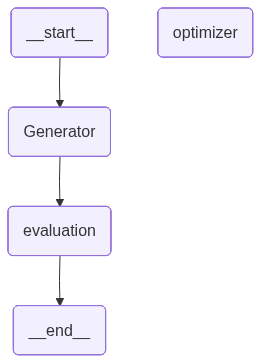

In [15]:
app